In [28]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock

from sympy import Matrix
from warnings import catch_warnings, simplefilter

from numpy import ceil, sqrt

import pandas as pd
import matplotlib.pyplot as plt

# import matplotlib as mpl
# mpl.rcParams["figure.dpi"] = 300

## 1 | Model Setup via YAML

`SymbolicDSGE` uses a YAML based configuration to define DSGE models. Examples of configurations can be found in the `MODELS` directory.
Parsed models are represented as `ModelConfig` objects, which allow detailed inspection of the inferred model structure.
Confirming the model setup is read as intended is strongly recommended and easy to achieve.

All expressions read from the configuration are converted to `SymPy` objects of the appropriate type. (`Expr`, `Function`, `Symbol`, etc.)
The project treats all variables as functions of time, using a variable `t: sp.Symbol` and defining time shifts via `sp.Function` objects.
To stay consistent with said scheme, variables in the configuration must be defined as functions, e.g. `c(t)`, `k(t-1)`, etc.

__NOTES:__
- OBC constraints are parsed and validated, but not enforced in the solver (yet).
- Model equations that refer to a lagged variable (e.g. `k(t-1)`) are shifted forward in time during parsing. For example `"x(t) = alpha*x(t-1) + eps(t)"` becomes `"x(t+1) = alpha*x(t) + eps(t+1)"` internally. The configuration does not require any modification to time indices.

In [29]:
model, kalman = ModelParser("../../MODELS/POST82.yaml").get_all()

with catch_warnings():
    # Equations in a sp.Matrix are deprecated, this is only used as a pretty print function
    simplefilter(action="ignore")
    mat = Matrix(list(model.equations.model.values()))
mat

Matrix([
[                                    Eq(Pi(t), beta*Pi(t + 1) + kappa*(x(t) - z(t)))],
[                           Eq(x(t), -tau_inv*(-Pi(t + 1) + r(t)) + g(t) + x(t + 1))],
[Eq(r(t), e_r + rho_r*r(t - 1*1) + (1 - rho_r)*(psi_pi*Pi(t) + psi_x*(x(t) - z(t))))],
[                                                   Eq(g(t), e_g + rho_g*g(t - 1*1))],
[                                                   Eq(z(t), e_z + rho_z*z(t - 1*1))]])

## 2 | Solving the Model

The `DSGESolver` class provides methods to solve and simulate DSGE models defined via `ModelConfig` objects.
The solver is kept simple and lightweight with a focus on small/medium scale linear models.
The solver is completely numeric and does not suffer from the performance issues brought by symbolic computation.
On the backend, `DSGESolver` converts all relevant `SymPy` expressions to `NumPy` based lambdas for fast evaluation.

The solution process consists of two main steps:
1. **Compilation**: The model equations are compiled into a numeric representation suitable for solving. This step requires the user to specify the variable order, number of state variables, and number of exogenous processes.

2. **Solving**: The compiled model is solved given a steady state and parameter values. The solution yields policy functions and transition dynamics.

In [30]:
solver = DSGESolver(model, kalman)
compiled = solver.compile(
    variable_order=None,  # None => as specified in model config
    params_order=None,  # None => as specified in model config
)
print("Equations with symbols removed: \n", "\n".join(map(str, compiled.objective_eqs)))
print("\n")
print("Equations as passed to the solver: \n", compiled.construct_objective_cfunc())

Equations with symbols removed: 
 -beta*fwd_Pi + cur_Pi - kappa*(cur_x - cur_z)
-cur_g + cur_x - fwd_x + tau_inv*(cur_r - fwd_Pi)
cur_r - e_r - prev_r*rho_r + (rho_r - 1)*(cur_Pi*psi_pi + psi_x*(cur_x - cur_z))
cur_g - e_g - prev_g*rho_g
cur_z - e_z - prev_z*rho_z


Equations as passed to the solver: 
 <Numba C callback '_residual_cf'>


As seen in above output, the solver is exposed to a single `Callable` representing the system of equations.
The function takes three arguments:
1. `fwd`: A 1D `np.ndarray` of shape `(n_vars,)` representing the variables at time `t+1`.
2. `cur`: A 1D `np.ndarray` of shape `(n_vars,)` representing the variables at time `t`.
3. `prev`: A 1D `np.ndarray` of shape `(n_vars,)` representing the variables at time `t-1`.
4. `eps`: A 1D `np.ndarray` of shape `(n_shocks,)` representing the exogenous shocks at time `t`.
5. `params`: A `dict` mapping parameter names to their numeric values.

With these 5 arguments, the entire system is converted to a numerical representation that can be evaluated in C.

In [31]:
sol = solver.solve(
    compiled,
    parameters=None,  # None => use "calibration" from model config
    ss_seed=[0.0, 0.0, 0.0, 0.0, 0.0],
)

print("Is stable: ", sol.policy.stab == 0)  # stable if sol.policy.stab == 0
print("Eigenvalues: ", sol.policy.eig.round(3))

Is stable:  True
Eigenvalues:  [0.28 +0.j 0.83 +0.j 0.85 +0.j 2.605+0.j 1.185+0.j]


## 3 | Transition Dynamics Check

`DSGESolver.solve` returns a `SolvedModel` object that comes with the methods necessary to inspect and validate the solution.
For example, IRFs with any unit shock can be generated as paths, and transition dynamics can be plotted.

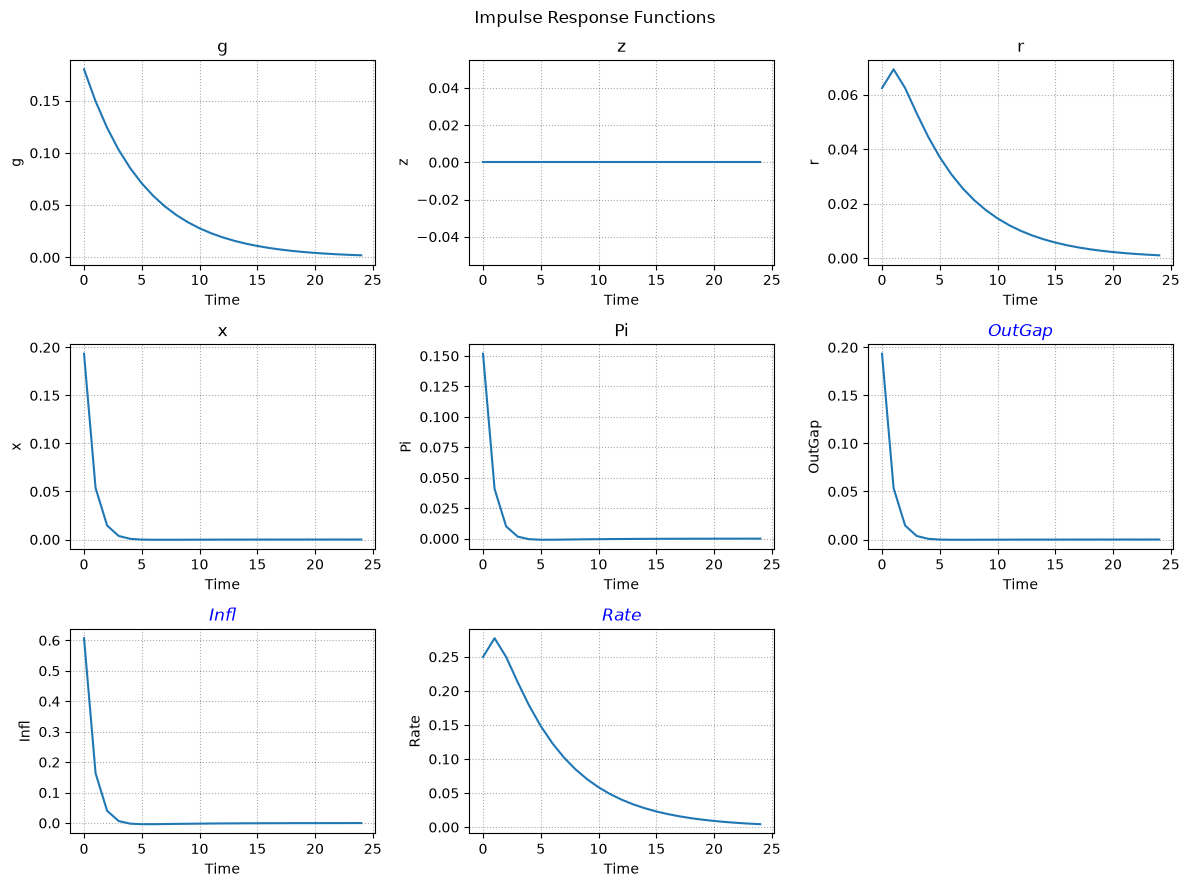

In [32]:
irf_dict = sol.irf(
    T=25,
    shocks=["e_g", "e_z"],
    scale=1.0,  # shock = sigma_var * scale
    observables=True,  # Include observables in output
)
sol.transition_plot(
    T=25,
    shocks=["e_g"],
    scale=1,
    observables=True,
)

In [33]:
irf_dict.states["z"].round(3)

array([0.64 , 0.544, 0.462, 0.393, 0.334, 0.284, 0.241, 0.205, 0.174,
       0.148, 0.126, 0.107, 0.091, 0.077, 0.066, 0.056, 0.048, 0.04 ,
       0.034, 0.029, 0.025, 0.021, 0.018, 0.015, 0.013])

The plot outputs have color-coded titles to indicate the type of variable:
- **Red**: Exogenous process
- **Black**: Model Variable (State/Jump)
- **Blue**: Observable

The output above confirms that the solution is indeed well-behaved and stable as all variables converge back to steady state with clearly defined dynamics.

## 4 | Simulation with Stochastic Shocks
The `SolvedModel.sim` method allows simulating the model over a specified time horizon with stochastic shocks.
The user can define shock specifications for each exogenous process, which produce shocks at each time step.
Alternatively, deterministic shocks can also be provided as a `np.ndarray`.
`SymbolicDSGE` uses the `Shock` class to facilitate the creation of various types of stochastic shocks.

A `Shock` object is horizon independent. `SolvedModel.sim` materializes it into a T period draw using the simulation horizon.
The distribution can be selected from "norm", "t", and "uni"; or any `SciPy` distribution that implements a `rvs` method. (formally, this requires the distribution to be a subclass of `rv_generic` from `scipy.stats._distn_infrastructure`. You can check if a given distribution meets this requirement by `isinstance(your_dist, rv_generic)` or `issubclass(your_dist, rv_generic)`.)

__NOTE:__ `Shock` specs use `sig_var` as the scale of the distribution when they are materialized by `SolvedModel.sim`. You will encounter an error if you pass a `scale` parameter in `dist_kwargs`.

In [34]:
T = 200
multi_shock_spec = lambda seed: Shock(
    dist="norm",
    multivar=True,
    seed=seed,
    dist_kwargs={
        "mean": [0.0, 0.0],
    },  # loc=0.0 is the default behavior, shown here for clarity.
)

uni_shock_spec = lambda seed: Shock(
    dist="norm",
    multivar=False,
    seed=seed,
    dist_kwargs={
        "loc": 0.0,
    },
)

sim_shocks = {
    "e_g,e_z": multi_shock_spec(seed=1),
    "e_r": uni_shock_spec(seed=2),
}  # Generate multivariate shocks for 'g' and 'z' (rho_gz != 0)
sim_data = sol.sim(
    T=T,
    x0=[0.0, 0.0, 0.0, 0.0, 0.0],  # Start at steady state
    shocks=sim_shocks,
    shock_scale=1.0,
    observables=True,
)

sim_df = pd.DataFrame(sim_data.states | sim_data.observables)
sim_df.head(10).round(3)

,g,z,r,x,Pi,OutGap,Infl,Rate
0,0.062,0.570,0.001,0.472,-0.080,0.472,3.110,6.445
1,0.111,-0.217,0.020,0.128,0.274,0.128,4.527,6.518
2,0.255,0.290,0.053,0.634,0.270,0.634,4.509,6.652
3,0.115,0.470,-0.118,1.319,0.674,1.319,6.127,5.969
4,0.161,0.659,0.094,0.264,-0.319,0.264,2.156,6.817
5,0.139,0.893,0.094,0.312,-0.467,0.312,1.563,6.815
6,-0.017,0.492,-0.027,0.350,-0.114,0.350,2.974,6.334
7,-0.101,0.665,-0.033,0.207,-0.365,0.207,1.969,6.308
8,-0.077,0.400,-0.041,0.204,-0.156,0.204,2.806,6.275
9,-0.204,0.006,-0.116,0.059,0.045,0.059,3.609,5.976


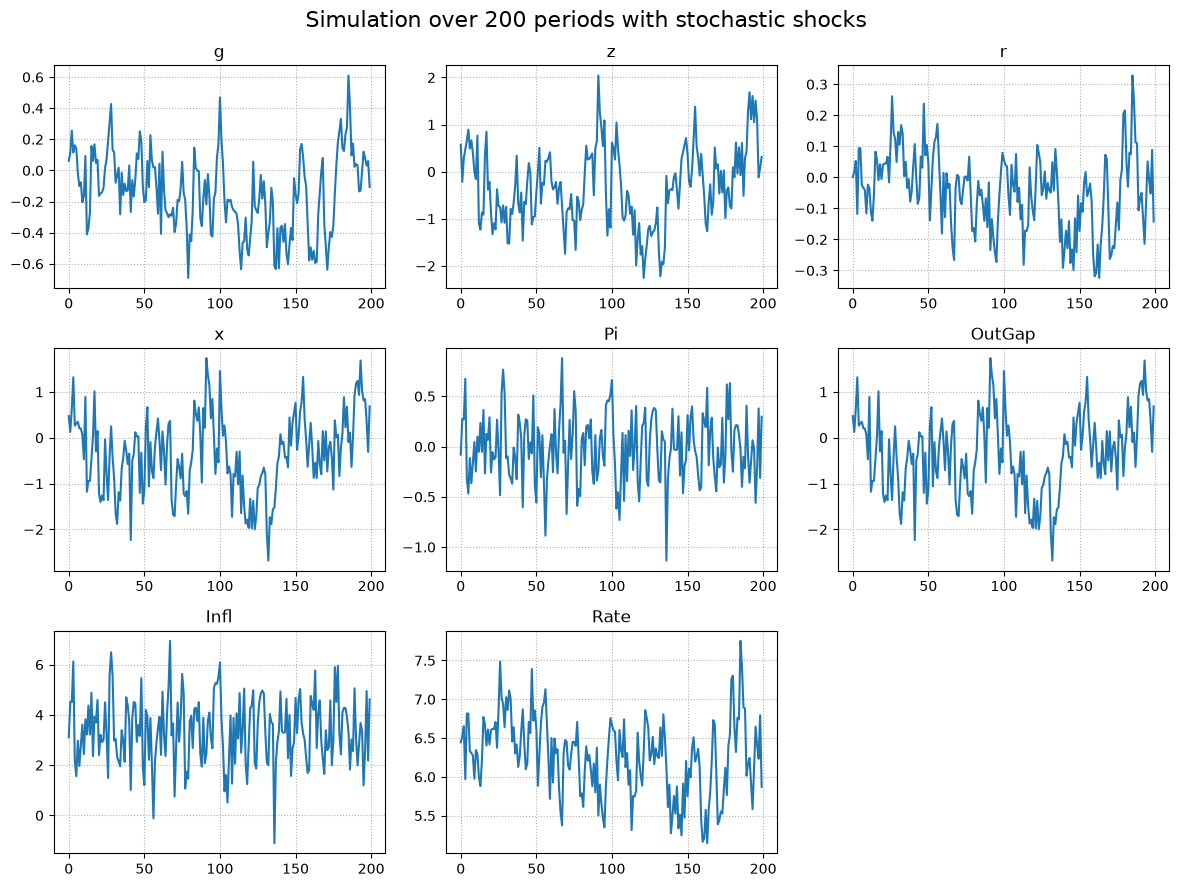

In [35]:
fig_square = ceil(sqrt(len(sim_df.columns))).astype(int)
size = (4 * fig_square, 3 * fig_square)
fig, ax = plt.subplots(fig_square, fig_square, figsize=size)
ax = ax.flatten()

while len(ax) > len(sim_df.columns):
    fig.delaxes(ax[-1])
    ax = ax[:-1]

for i, (var, path) in enumerate(sim_df.items()):
    ax[i].plot(path)
    ax[i].set_title(var)
    ax[i].grid(linestyle=":")
plt.suptitle(f"Simulation over {T} periods with stochastic shocks", fontsize=16)
plt.tight_layout()